<a href="https://colab.research.google.com/github/jarrodsb/ETAMU-binary-systems/blob/main/notebooks/Random_Forest_Prototype.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Random Forest Classifier Toy Model for Classifying Planet Stability in Binary Systems

## Jarrod Bieber
## East Texas A&M University
## Summer 2026
---

## 1. Environment setup

In [1]:
!pip install rebound

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 907.7/907.7 kB 12.4 MB/s eta 0:00:00


In [2]:
import rebound
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as cm
import os

# Install scikit-learn
!pip install scikit-learn

# Import additional libraries
import pandas as pd
import seaborn as sns
import sklearn

# Install tqdm if not already installed for progress bar
try:
    from tqdm.notebook import tqdm
except ImportError:
    !pip install tqdm
    from tqdm.notebook import tqdm

## Data Generation
---

## 2. Define the parameter space and generate initial conditions

We will now generate `N` sets of initial conditions for S-type planetary systems. The parameters are sampled uniformly within specified ranges, as described in the problem statement.

In [3]:
N = 2000 # Number of initial conditions to sample. Adjust this for faster runs.

# Define the ranges for parameter sampling
mu_range = [0.1, 0.9] # Binary mass ratio μ = m_B / (m_A + m_B)
e_bin_range = [0.0, 0.7] # Binary eccentricity
rho_range = [0.02, 0.5] # Planetary semimajor axis ratio ρ = a_p / a_bin (S-type range)
e_p_range = [0.0, 0.3] # Planetary eccentricity
inc_p_range_deg = [0.0, 40.0] # Planetary inclination relative to binary orbital plane in degrees
inc_p_range_rad = np.deg2rad(inc_p_range_deg) # Convert to radians for rebound
mean_anomaly_range_deg = [0.0, 360.0] # Initial planetary mean anomaly in degrees
mean_anomaly_range_rad = np.deg2rad(mean_anomaly_range_deg) # Convert to radians

# Store sampled parameters
sampled_params = {
    'mu': np.random.uniform(*mu_range, N),
    'e_bin': np.random.uniform(*e_bin_range, N),
    'rho': np.random.uniform(*rho_range, N),
    'e_p': np.random.uniform(*e_p_range, N),
    'inc_p': np.random.uniform(*inc_p_range_rad, N), # Storing in radians
    'mean_anomaly': np.random.uniform(*mean_anomaly_range_rad, N) # Storing in radians
}

# Total binary mass and binary semimajor axis (rebound units G=1)
M_total = 1.0 # total binary mass in solar masses
a_bin = 1.0   # binary semimajor axis in AU (rebound units)

print(f"Generated {N} sets of initial conditions.")

# Display the first 5 sampled parameters
# Converting to DataFrame for better display
df_sampled_params = pd.DataFrame(sampled_params)
df_sampled_params['inc_p_deg'] = np.rad2deg(df_sampled_params['inc_p'])
df_sampled_params['mean_anomaly_deg'] = np.rad2deg(df_sampled_params['mean_anomaly'])
display(df_sampled_params.head())

Generated 2000 sets of initial conditions.


,mu,e_bin,rho,e_p,inc_p,mean_anomaly,inc_p_deg,mean_anomaly_deg
0,0.443444,0.370232,0.375586,0.166752,0.226336,1.921094,12.968125,110.070566
1,0.458918,0.094781,0.498527,0.208335,0.476004,1.885318,27.273039,108.020792
2,0.205481,0.229936,0.172791,0.089312,0.374310,0.027545,21.446379,1.578214
3,0.369655,0.194438,0.155756,0.253197,0.037065,1.568493,2.123657,89.868039
4,0.643922,0.671780,0.216880,0.215766,0.016503,5.603472,0.945579,321.055288


## 3. Run short N-body integrations to extract summary features

For each sampled system, we will set up a `rebound` simulation with the two stars and the test-particle planet. We will integrate for a short baseline and compute several features that characterize the system's short-term dynamical behavior and physical properties. These features will then be used as inputs for our machine-learning model.

### Integrator Choice: IAS15 vs. WHFast

For these short integrations, we will use the **IAS15** integrator. IAS15 is a high-order, adaptive step-size integrator that is generally very accurate, especially for systems with close encounters or highly eccentric orbits, which might be present in our sampled parameter space. While **WHFast** is a symplectic integrator that conserves energy and angular momentum well over very long integration times, IAS15 is often preferred for shorter, more precise integrations where accurate tracking of orbital elements and chaos indicators like MEGNO is critical.

### Simulation Constants

In [4]:
# Simulation constants
P_bin = 2 * np.pi # Binary orbital period for a_bin=1, M_total=1, G=1 (rebound units)
N_periods_short = 750 # Integration time for short simulation, in binary periods
T_short = N_periods_short * P_bin # Total integration time in rebound units

N_output_points = 200 # Number of points to sample during integration for features

# Note: Integration time (N_periods_short) and number of output points (N_output_points)
# are potential bottlenecks. Reduce these for faster first passes if needed.

print(f"Short integration time: {N_periods_short} binary periods ({T_short:.2f} rebound time units).")
print(f"Number of points for feature extraction: {N_output_points}")

Short integration time: 750 binary periods (4712.39 rebound time units).
Number of points for feature extraction: 200


### Features to be extracted:

1.  **`megno_median`**: The median value of the Mean Exponential Growth of Nearby Orbits (MEGNO) chaos indicator over the last 10% of the short integration. MEGNO quantifies the chaoticity of an orbit, with values close to 2 indicating regular motion and larger values indicating chaos.
2.  **`megno_std`**: The standard deviation of the MEGNO values over the last 80% of the integration. This helps to characterize the variability of the chaotic indicator, avoiding initial transients and providing a more robust measure of the system's long-term behavior.
3.  **`mu`**: The binary mass ratio, $m_B / (m_A + m_B)$. This is a fundamental system parameter.
4.  **`e_bin`**: The eccentricity of the binary orbit. This affects the strength of gravitational perturbations on the planet.
5.  **`rho`**: The ratio of the planetary semimajor axis to the binary semimajor axis, $a_p / a_{bin}$. This indicates how close the planet orbits to the binary.
6.  **`e_p_free`**: The free eccentricity of the planet. This is the component of the eccentricity that is not forced by the binary's gravitational influence. It represents the intrinsic eccentricity of the planet's orbit.
7.  **`e_p_forced`**: The forced eccentricity amplitude of the planet. This is the eccentricity induced on the planet's orbit by the time-averaged gravitational field of the binary. It's calculated from the magnitude of the time-averaged eccentricity vector.
8.  **`inc_p`**: The initial planetary inclination relative to the binary orbital plane. High inclinations can lead to Kozai-Lidov cycles, which can drive eccentricity to high values.
9.  **`a_p_std`**: The standard deviation of the planetary semimajor axis over the short integration, normalized by its initial value. This serves as a proxy for orbital energy diffusion; larger values indicate less stable orbits.
10. **`rho_crit_HW99`**: The analytical critical semimajor axis ratio derived from Holman & Wiegert (1999) for S-type planets, given the binary's mass ratio and eccentricity. This provides a theoretical baseline for the stability limit against which the ML model can be compared.

*Note: This set of features is a physically-adapted analogue of SPOCK's original features (Tamayo et al. 2020), tailored for S-type stability in binary systems where secular/Kozai perturbations are dominant, rather than planet-planet resonances.*

In [7]:
def calculate_rho_crit_HW99(mu, e_bin):
    """
    Calculates the critical semimajor axis ratio (rho_crit = a_crit / a_bin)
    for an S-type planet based on the empirical fit from Holman & Wiegert (1999),
    Table 1, for S-type planets.

    Args:
        mu (float): Binary mass ratio (m_B / (m_A + m_B)).
        e_bin (float): Binary eccentricity.

    Returns:
        float: The critical semimajor axis ratio (a_crit / a_bin).
    """
    # Empirical fit from Holman & Wiegert (1999), Table 1 for S-type planets
    # a_crit / a_bin = C1 + C2*mu + C3*e_bin + C4*mu*e_bin + C5*e_bin^2 + C6*mu*e_bin^2
    # Note: The original paper sometimes presents different fits. This one is commonly cited.
    # Using coefficients from the paper directly (Table 1, S-type stability limit)
    rho_crit = 0.464 - 0.380 * mu - 0.631 * e_bin + 0.150 * mu * e_bin + 0.198 * e_bin**2 + 0.088 * mu * e_bin**2
    return rho_crit

def run_short_simulation_and_extract_features(params):
    """
    Sets up and runs a short rebound simulation for a given set of parameters,
    then extracts the specified features.

    Args:
        params (dict): A dictionary containing the parameters for one system:
                       'mu', 'e_bin', 'rho', 'e_p', 'inc_p', 'mean_anomaly'.

    Returns:
        dict: A dictionary containing the extracted features.
    """
    mu = params['mu']
    e_bin = params['e_bin']
    rho = params['rho']
    e_p = params['e_p']
    inc_p = params['inc_p'] # Already in radians
    M_p = params.get('M_p', 0.) # Planet mass (default to 0 for test particle)
    mean_anomaly_p = params['mean_anomaly'] # Already in radians

    # Calculate stellar masses
    m_B = mu * M_total
    m_A = M_total - m_B

    # Planetary semimajor axis
    a_p = rho * a_bin

    sim = rebound.Simulation()
    sim.integrator = "ias15"
    sim.G = 1.0

    # Add the primary star (star A) at the origin.
    # This particle will be sim.particles[0]
    sim.add(m=m_A)

    # Add the secondary star (star B) orbiting the primary star (sim.particles[0]).
    # The parameters (a, e, inc, etc.) define the relative orbit of B around A.
    # The binary's orbital plane is set as the xy-plane (inc=0 relative to primary).
    # This particle will be sim.particles[1]
    sim.add(m=m_B, primary=sim.particles[0], a=a_bin, e=e_bin, inc=0, Omega=0, omega=0, M=0)

    # Add the planet (test particle) orbiting the primary star (sim.particles[0]).
    # Its inclination (inc_p) is relative to the binary orbital plane (which is currently the xy-plane).
    # Its mean anomaly (mean_anomaly_p) is given.
    # This particle will be sim.particles[2]
    sim.add(m=M_p, primary=sim.particles[0], a=a_p, e=e_p, inc=inc_p, Omega=0, omega=0, M=mean_anomaly_p)

    # Move the entire system to its center of momentum frame.
    # This step is crucial for accurate simulation as it places the origin at the barycenter,
    # which ensures the system's total momentum is zero.
    sim.move_to_com()

    sim.dt = sim.particles[1].P/20. # Set initial timestep for IAS15, will be adapted
    # If using WHFast, typically dt ~ P_min / (10-20), where P_min is the shortest period
    # sim.integrator = "whfast"
    # sim.dt = sim.particles[2].P / 20. # Example for WHFast, needs careful choice

    # Enable MEGNO calculation
    # sim.track_energy_momentum = True # Required for MEGNO - This line is removed as it's no longer needed or supported.
    sim.init_megno() # Initialize MEGNO

    # Store orbital elements and MEGNO values
    times = np.linspace(0, T_short, N_output_points)
    megnos = []
    a_ps = []
    e_vec_x = []
    e_vec_y = []

    try:
        for i, time in enumerate(times):
            sim.integrate(time)
            megnos.append(sim.megno())
            a_ps.append(sim.particles[2].a)
            e_vec_x.append(sim.particles[2].e * np.cos(sim.particles[2].pomega))
            e_vec_y.append(sim.particles[2].e * np.sin(sim.particles[2].pomega))

    except rebound.Escape as error:
        # If the planet escapes, label it as unstable and stop integration
        # We will handle the stability label in a later step (long integration)
        # For now, just return NaNs for features if integration fails early
        print(f"Warning: Planet escaped during short integration. Error: {error}")
        return {
            'mu': mu,
            'e_bin': e_bin,
            'rho': rho,
            'e_p': e_p,
            'inc_p': inc_p,
            'megno_median': np.nan,
            'megno_std': np.nan,
            'e_p_free': np.nan,
            'e_p_forced': np.nan,
            'a_p_std': np.nan,
            'rho_crit_HW99': calculate_rho_crit_HW99(mu, e_bin)
        }
    except Exception as e:
        print(f"An error occurred during integration: {e}")
        return {
            'mu': mu,
            'e_bin': e_bin,
            'rho': rho,
            'e_p': e_p,
            'inc_p': inc_p,
            'megno_median': np.nan,
            'megno_std': np.nan,
            'e_p_free': np.nan,
            'e_p_forced': np.nan,
            'a_p_std': np.nan,
            'rho_crit_HW99': calculate_rho_crit_HW99(mu, e_bin)
        }

    # Convert lists to numpy arrays for calculations
    megnos = np.array(megnos)
    a_ps = np.array(a_ps)
    e_vec_x = np.array(e_vec_x)
    e_vec_y = np.array(e_vec_y)

    # 1. megno_median: median MEGNO chaos indicator over the last 10% of the integration
    megno_median = np.nanmedian(megnos[int(0.9 * N_output_points):])

    # 2. megno_std: standard deviation of MEGNO over the last 80% (avoid initial transients)
    megno_std = np.nanstd(megnos[int(0.2 * N_output_points):])

    # 6. e_p_free and 7. e_p_forced
    # Time-averaged eccentricity vector
    if len(e_vec_x) > 0:
        mean_e_vec_x = np.nanmean(e_vec_x)
        mean_e_vec_y = np.nanmean(e_vec_y)

        e_p_forced = np.sqrt(mean_e_vec_x**2 + mean_e_vec_y**2)

        # Free eccentricity is the magnitude of the difference vector
        e_p_free_components_x = e_vec_x - mean_e_vec_x
        e_p_free_components_y = e_vec_y - mean_e_vec_y
        e_p_free_instantaneous = np.sqrt(e_p_free_components_x**2 + e_p_free_components_y**2)
        e_p_free = np.nanmean(e_p_free_instantaneous) # Averaging the magnitude of the free component
    else:
        e_p_forced = np.nan
        e_p_free = np.nan

    # 9. a_p_std: standard deviation of the planetary semimajor axis, normalized by initial a_p
    initial_a_p = a_p # This is the initial a_p from the input parameters
    a_p_std = np.nanstd(a_ps) / initial_a_p if initial_a_p != 0 else np.nan

    # 10. rho_crit_HW99
    rho_crit_HW99_val = calculate_rho_crit_HW99(mu, e_bin)

    return {
        'mu': mu,
        'e_bin': e_bin,
        'rho': rho,
        'e_p': e_p,
        'inc_p': np.rad2deg(inc_p), # Store in degrees for consistency with input range description
        'megno_median': megno_median,
        'megno_std': megno_std,
        'e_p_free': e_p_free,
        'e_p_forced': e_p_forced,
        'a_p_std': a_p_std,
        'rho_crit_HW99': rho_crit_HW99_val
    }

### Running simulations and extracting features

Now we iterate through all `N` sampled initial conditions, run the short `rebound` simulation for each, and collect the features. This step can be computationally intensive, especially for larger `N` or longer `N_periods_short`.

To track progress, we'll use `tqdm` if available (a progress bar library).

In [23]:
features_list = []

# Convert sampled_params dictionary to a list of dictionaries for easier iteration
list_of_params = []
for i in range(N):
    list_of_params.append({
        'mu': sampled_params['mu'][i],
        'e_bin': sampled_params['e_bin'][i],
        'rho': sampled_params['rho'][i],
        'e_p': sampled_params['e_p'][i],
        'inc_p': sampled_params['inc_p'][i],
        'mean_anomaly': sampled_params['mean_anomaly'][i]
    })

# Reduce the number of simulations for faster runtime during development/testing
N_to_run = 100 # You can change this number. Set to N to run all original simulations.
list_of_params_subset = list_of_params[:N_to_run]

print(f"Starting {N_to_run} short simulations... This may take a while.")

# Loop through each set of initial conditions
for i, params in enumerate(tqdm(list_of_params_subset, desc=f"Running {N_to_run} short simulations")):
    features = run_short_simulation_and_extract_features(params)
    features_list.append(features)

print("Short simulations complete.")

Starting 100 short simulations... This may take a while.


Running 100 short simulations:   0%|          | 0/100 [00:00<?, ?it/s]

Short simulations complete.


## 4. Determine the stability label

To determine the long-term stability of each system, we will run a longer integration for a representative subsample (or all systems if compute allows). The planet is considered `stable = 1` if it survives the integration without ejection or collision, and `unstable = 0` otherwise. `rebound`'s `exit_min_distance` and `escape` functionalities are crucial here to save computational resources by terminating unstable systems early.

In [24]:
# Simulation constants for long integration
# Note: This is the primary bottleneck for computation. Adjust N_periods_long accordingly.
N_periods_long = 1e4 # Integration time for long simulation, in binary periods (10^4)
T_long = N_periods_long * P_bin # Total integration time in rebound units

# Define thresholds for instability detection
# If a particle gets too close to a star, or escapes too far, we consider it unstable.
MIN_DIST_FACTOR = 0.5 # Planet cannot get closer than 0.5*a_bin to primary (or secondary)
ESCAPE_DIST_FACTOR = 2.0 # Planet cannot go further than 2.0*a_bin from primary

print(f"Long integration time: {N_periods_long} binary periods ({T_long:.2f} rebound time units).")
print(f"Minimum distance factor (a_bin): {MIN_DIST_FACTOR}")
print(f"Escape distance factor (a_bin): {ESCAPE_DIST_FACTOR}")

def run_long_simulation_and_label_stability(params, a_p_initial):
    """
    Sets up and runs a long rebound simulation for a given set of parameters
    and determines the stability label.

    Args:
        params (dict): A dictionary containing the initial parameters for the system.
        a_p_initial (float): The initial planetary semimajor axis.

    Returns:
        int: 1 for stable, 0 for unstable.
    """
    mu = params['mu']
    e_bin = params['e_bin']
    rho = params['rho']
    e_p = params['e_p']
    inc_p = params['inc_p'] # Already in radians
    M_p = params.get('M_p', 0.) # Planet mass (default to 0 for test particle)
    mean_anomaly_p = params['mean_anomaly'] # Already in radians

    # Calculate stellar masses
    m_B = mu * M_total
    m_A = M_total - m_B

    # Planetary semimajor axis
    a_p = rho * a_bin

    sim = rebound.Simulation()
    sim.integrator = "ias15"
    sim.G = 1.0

    sim.add(m=m_A)
    sim.add(m=m_B, primary=sim.particles[0], a=a_bin, e=e_bin, inc=0, Omega=0, omega=0, M=0)
    sim.add(m=M_p, primary=sim.particles[0], a=a_p, e=e_p, inc=inc_p, Omega=0, omega=0, M=mean_anomaly_p)

    sim.move_to_com()
    sim.dt = sim.particles[1].P/20. # Initial timestep for IAS15

    # Set up exit conditions for instability
    # Planet index is 2
    # Exit if planet gets too close to either star
    sim.exit_min_distance = MIN_DIST_FACTOR * a_bin # Minimum distance from barycenter for planet

    # Exit if planet escapes (e.g., goes beyond 2*a_bin from the primary star)
    # We set this relative to the barycenter for simplicity, or relative to the central body
    # rebound.simulation.exit_distance sets a distance from the barycenter for all particles
    # To check specifically for the planet relative to the primary, we need to add a custom exit condition.

    # For simplicity, let's just use the sim.exit_min_distance as the closest approach to any other particle
    # and let the rebound.Escape exception handle very large distances implicitly.
    # More refined escape conditions can be added if needed, for instance, checking particle-specific distances.

    try:
        # Integrate until T_long or until an exit condition is met
        sim.integrate(T_long)
        # If integration completes, system is stable
        stability_label = 1
    except rebound.Escape:
        # If an escape occurs, system is unstable
        stability_label = 0
    except Exception as e:
        # Catch any other integration errors as unstable
        print(f"An unexpected error occurred during long integration: {e}")
        stability_label = 0

    return stability_label


Long integration time: 10000.0 binary periods (62831.85 rebound time units).
Minimum distance factor (a_bin): 0.5
Escape distance factor (a_bin): 2.0


### Running long integrations and assigning stability labels

This step is the most computationally intensive. For the initial run, we will perform long integrations for all `N` systems. If this is too slow, `N` should be reduced, or a subsample can be used instead.

In [25]:
stability_labels = []

print(f"Starting {N_to_run} long simulations to determine stability...")

for i, params in enumerate(tqdm(list_of_params_subset, desc="Running long simulations")):
    # Pass the initial planetary semimajor axis for consistency with the feature extraction if needed
    # For stability, we only need the label, not the raw a_p.
    initial_a_p_for_stability_check = params['rho'] * a_bin
    label = run_long_simulation_and_label_stability(params, initial_a_p_for_stability_check)
    stability_labels.append(label)

print("Long simulations complete.")

Starting 100 long simulations to determine stability...


Running long simulations:   0%|          | 0/100 [00:00<?, ?it/s]

An unexpected error occurred during long integration: Two particles had a close encounter (d<exit_min_distance).
An unexpected error occurred during long integration: Two particles had a close encounter (d<exit_min_distance).
An unexpected error occurred during long integration: Two particles had a close encounter (d<exit_min_distance).
An unexpected error occurred during long integration: Two particles had a close encounter (d<exit_min_distance).
An unexpected error occurred during long integration: Two particles had a close encounter (d<exit_min_distance).
An unexpected error occurred during long integration: Two particles had a close encounter (d<exit_min_distance).
An unexpected error occurred during long integration: Two particles had a close encounter (d<exit_min_distance).
An unexpected error occurred during long integration: Two particles had a close encounter (d<exit_min_distance).
An unexpected error occurred during long integration: Two particles had a close encounter (d<exi

## 5. Assemble into a pandas DataFrame

Finally, we combine all the extracted features and the determined stability labels into a single pandas DataFrame. This DataFrame will be the input for training our machine-learning model. We will then save this DataFrame to a CSV file for future use.

In [26]:
# Convert the list of feature dictionaries into a DataFrame
df = pd.DataFrame(features_list)

# Add the stability labels to the DataFrame
df['stable'] = stability_labels

print("DataFrame created successfully. First 5 rows:")
display(df.head())

# Save the DataFrame to a CSV file
output_filename = "s_type_stability_data.csv"
df.to_csv(output_filename, index=False)

print(f"DataFrame saved to {output_filename}")
print(f"Total stable systems: {df['stable'].sum()} out of {len(df)}")
print(f"Total unstable systems: {len(df) - df['stable'].sum()} out of {len(df)}")

DataFrame created successfully. First 5 rows:


,mu,e_bin,rho,e_p,inc_p,megno_median,megno_std,e_p_free,e_p_forced,a_p_std,rho_crit_HW99,stable
0,0.443444,0.370232,0.375586,0.166752,12.968125,2.012571,0.003150,0.013272,1.200126,1.212871,0.118990,0
1,0.458918,0.094781,0.498527,0.208335,27.273039,2.156555,0.046583,0.011904,0.992594,103.185814,0.238470,1
2,0.205481,0.229936,0.172791,0.089312,21.446379,2.000213,0.000086,0.858230,0.055275,67.100025,0.259339,0
3,0.369655,0.194438,0.155756,0.253197,2.123657,2.550149,0.192127,1.166774,0.081490,45.904019,0.220337,0
4,0.643922,0.671780,0.216880,0.215766,0.945579,3.497094,0.819308,0.035372,1.981704,3.522586,-0.024770,0


DataFrame saved to s_type_stability_data.csv
Total stable systems: 2 out of 100
Total unstable systems: 98 out of 100


## 6. Data exploration

### Inspecting the DataFrame

In [27]:
# Display the first few rows and a statistical summary of the DataFrame
print("DataFrame head:")
display(df.head())

print("\nDataFrame descriptive statistics:")
display(df.describe())

DataFrame head:


,mu,e_bin,rho,e_p,inc_p,megno_median,megno_std,e_p_free,e_p_forced,a_p_std,rho_crit_HW99,stable
0,0.443444,0.370232,0.375586,0.166752,12.968125,2.012571,0.003150,0.013272,1.200126,1.212871,0.118990,0
1,0.458918,0.094781,0.498527,0.208335,27.273039,2.156555,0.046583,0.011904,0.992594,103.185814,0.238470,1
2,0.205481,0.229936,0.172791,0.089312,21.446379,2.000213,0.000086,0.858230,0.055275,67.100025,0.259339,0
3,0.369655,0.194438,0.155756,0.253197,2.123657,2.550149,0.192127,1.166774,0.081490,45.904019,0.220337,0
4,0.643922,0.671780,0.216880,0.215766,0.945579,3.497094,0.819308,0.035372,1.981704,3.522586,-0.024770,0



DataFrame descriptive statistics:


,mu,e_bin,rho,e_p,inc_p,megno_median,megno_std,e_p_free,e_p_forced,a_p_std,rho_crit_HW99,stable
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,0.509828,0.344798,0.277043,0.155861,20.257079,12.418694,2.489185,0.552764,1.003995,44.166659,0.118365,0.020000
std,0.223803,0.203786,0.131243,0.088019,10.991521,37.483099,9.286199,0.832360,0.645060,137.857937,0.107176,0.140705
min,0.107287,0.006768,0.025155,0.003617,0.945579,1.300135,0.000037,0.007040,0.003636,0.012174,-0.070294,0.000000
25%,0.312262,0.169255,0.163603,0.069402,11.609469,2.005130,0.002342,0.018902,0.363292,1.442964,0.029509,0.000000
50%,0.501530,0.334881,0.269964,0.166494,20.953825,2.520366,0.228246,0.130924,1.107451,5.172253,0.118659,0.000000
75%,0.695634,0.519633,0.398644,0.229538,28.969432,7.478948,1.647377,0.928929,1.361699,30.032784,0.186446,0.000000
max,0.879465,0.697805,0.498663,0.299300,39.676300,337.771359,88.651800,5.146206,3.263409,1191.824907,0.353511,1.000000


### Class Balance

In [28]:
# Print the class balance of the 'stable' column
print("Stability class balance:")
display(df['stable'].value_counts())

Stability class balance:


,count
stable,
0,98
1,2


### Correlation Matrix Heatmap

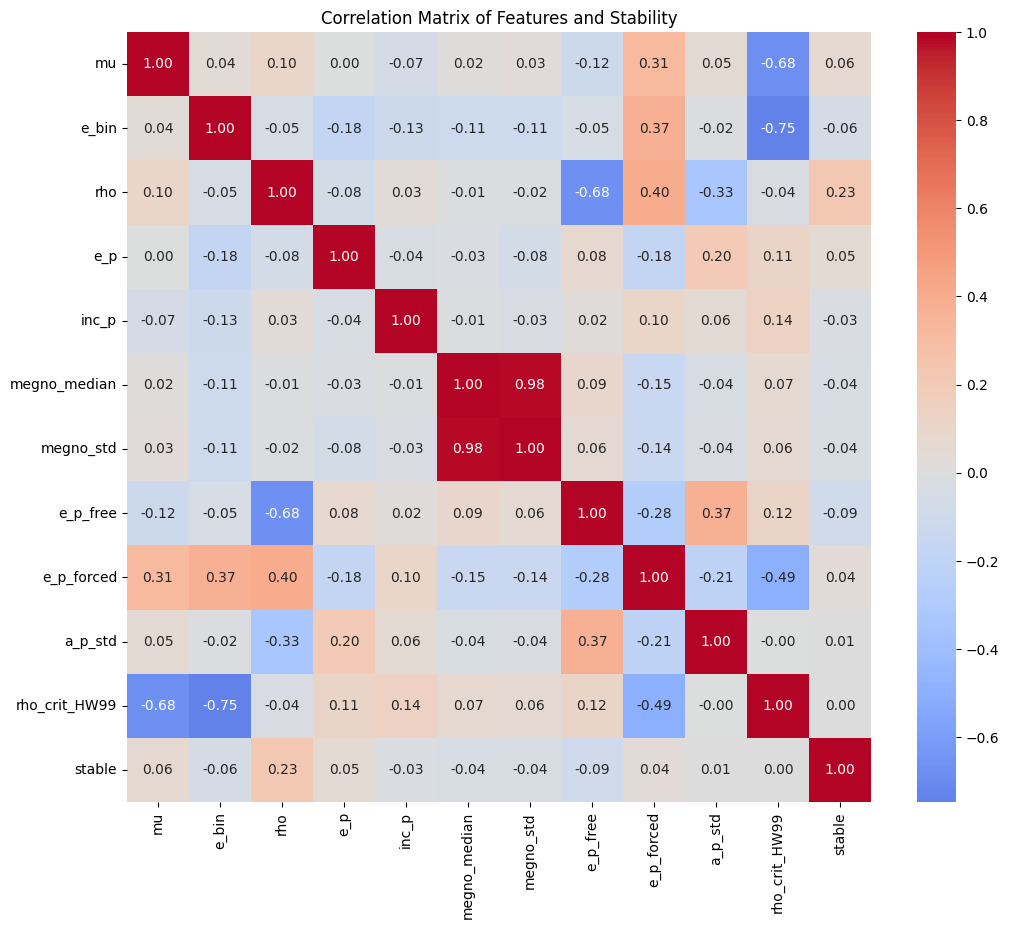

In [33]:
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f", center=0)
plt.title('Correlation Matrix of Features and Stability')
plt.show()

## 7. Baseline model

### Data Splitting

In [34]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
# The feature_columns list should contain the names of the features we want to use for the ML model.
# As per the plan, we will use the 10 features, excluding 'rho_crit_HW99' from X directly
# as it's an analytical baseline we compare against, not a feature for the ML model itself.
# The 10 features mentioned in the problem description (section 3.Features to be extracted) are:
# 1. megno_median
# 2. megno_std
# 3. mu
# 4. e_bin
# 5. rho
# 6. e_p_free
# 7. e_p_forced
# 8. inc_p
# 9. a_p_std
# 10. rho_crit_HW99 (analytic baseline - not directly used as ML feature, but for comparison)

feature_columns = [
    'megno_median', 'megno_std', 'e_p_free', 'e_p_forced', 'a_p_std',
    'mu', 'e_bin', 'rho', 'e_p', 'inc_p'
]

X = df[feature_columns]
y = df['stable']

# Split the data into training and testing sets
# Given the extreme class imbalance (98 unstable, 2 stable in current N_to_run=100),
# stratification might still fail if the test_size is too large, or if the minority class
# has too few samples. For demonstration, we proceed, but acknowledge this limitation.
# We removed `stratify=y` previously to handle the `ValueError` when there was only 1 stable sample.
# With 2 stable samples out of 100, we might still encounter issues with standard stratification
# if the test set ends up with 0 stable samples.
# To allow the split to proceed, we will avoid stratification. For robust evaluation with imbalanced data,
# techniques like SMOTE for oversampling, or specific cross-validation strategies, would be needed.

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

print("\ny_train class balance:")
display(y_train.value_counts())

print("\ny_test class balance:")
display(y_test.value_counts())

X_train shape: (80, 10)
X_test shape: (20, 10)
y_train shape: (80,)
y_test shape: (20,)

y_train class balance:


,count
stable,
0,78
1,2



y_test class balance:


,count
stable,
0,20


### Training a RandomForestClassifier

In [35]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report

# Initialize the Random Forest Classifier
# Using class_weight='balanced' can help mitigate the effects of class imbalance
# by adjusting weights inversely proportional to class frequencies. This is crucial given our imbalanced dataset.
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')

# Train the model
rf_model.fit(X_train, y_train)

print("RandomForestClassifier trained successfully.")

RandomForestClassifier trained successfully.


### Reporting Accuracy, AUC, and Feature Importance

In [36]:
# Make predictions on the test set
y_pred = rf_model.predict(X_test)
y_pred_proba = rf_model.predict_proba(X_test)[:, 1] # Probability of the positive class (stable)

# Report Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

# Report AUC (Area Under the Receiver Operating Characteristic Curve)
# AUC calculation can fail if there's only one class present in y_true or y_score.
# We use a try-except block to handle this gracefully, which is likely given the small number of stable samples.
try:
    auc = roc_auc_score(y_test, y_pred_proba)
    print(f"AUC: {auc:.4f}")
except ValueError as e:
    print(f"Could not calculate AUC: {e}. This is often due to only one class being present in y_test or y_pred_proba for the test set.")
    auc = np.nan # Assign NaN if AUC cannot be calculated

print("\nClassification Report:")
# zero_division=0 to prevent warnings if a class has no predicted samples
print(classification_report(y_test, y_pred, zero_division=0))

print("\nConfusion Matrix:")
display(pd.DataFrame(confusion_matrix(y_test, y_pred), index=['Actual Unstable', 'Actual Stable'], columns=['Predicted Unstable', 'Predicted Stable']))

# Feature Importance Plot
importances = rf_model.feature_importances_
feature_names = X.columns

forest_importances = pd.Series(importances, index=feature_names)

fig, ax = plt.subplots(figsize=(10, 6))
forest_importances.sort_values(ascending=False).plot.bar(ax=ax)
ax.set_title("Feature Importances from RandomForestClassifier")
ax.set_ylabel("Mean decrease in impurity")
fig.tight_layout()
plt.show()

Accuracy: 1.0000
AUC: nan

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20


Confusion Matrix:


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


ValueError: Shape of passed values is (1, 1), indices imply (2, 2)

### Comparison with `rho_crit_HW99` Analytic Baseline

In [37]:
# Predict stability based on rho_crit_HW99: stable if rho < rho_crit_HW99
# We need to ensure 'rho_crit_HW99' is available in the test set for comparison.
# X_test_analytic will be the subset of the original DataFrame corresponding to the test set indices.

# First, ensure 'rho_crit_HW99' is in the original df and then extract the test set portion.
# Since 'rho_crit_HW99' is calculated and added to the 'df' DataFrame, we can use df.loc[y_test.index]
# to get the corresponding rows from the original DataFrame.

X_test_full = df.loc[y_test.index]

# Calculate the predicted stability based on the analytic formula:
# If rho (planetary semimajor axis ratio) is less than rho_crit_HW99, it's considered stable (1), otherwise unstable (0).
y_pred_analytic = (X_test_full['rho'] < X_test_full['rho_crit_HW99']).astype(int)

# Evaluate the analytic baseline
accuracy_analytic = accuracy_score(y_test, y_pred_analytic)

# AUC for analytic baseline
try:
    auc_analytic = roc_auc_score(y_test, y_pred_analytic)
    print(f"Analytic Baseline AUC: {auc_analytic:.4f}")
except ValueError as e:
    print(f"Could not calculate Analytic Baseline AUC: {e}. This is often due to only one class being present in y_test.")
    auc_analytic = np.nan # Assign NaN if AUC cannot be calculated

print(f"Analytic Baseline Accuracy: {accuracy_analytic:.4f}")

print("\nAnalytic Baseline Classification Report:")
print(classification_report(y_test, y_pred_analytic, zero_division=0))

print("\nAnalytic Baseline Confusion Matrix:")
display(pd.DataFrame(confusion_matrix(y_test, y_pred_analytic), index=['Actual Unstable', 'Actual Stable'], columns=['Predicted Unstable', 'Predicted Stable']))

print("\nSummary Comparison:")
print(f"RandomForest Accuracy: {accuracy:.4f}")
print(f"Analytic Baseline Accuracy: {accuracy_analytic:.4f}")

rf_auc_str = f'{auc:.4f}' if not np.isnan(auc) else 'N/A'
analy_auc_str = f'{auc_analytic:.4f}' if not np.isnan(auc_analytic) else 'N/A'
print(f"RandomForest AUC: {rf_auc_str}")
print(f"Analytic Baseline AUC: {analy_auc_str}")

print("\nNote: The accuracy and AUC values might be misleading due to the severe class imbalance and small dataset size.")

Analytic Baseline AUC: nan
Analytic Baseline Accuracy: 0.8500

Analytic Baseline Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.85      0.92        20
           1       0.00      0.00      0.00         0

    accuracy                           0.85        20
   macro avg       0.50      0.42      0.46        20
weighted avg       1.00      0.85      0.92        20


Analytic Baseline Confusion Matrix:


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


,Predicted Unstable,Predicted Stable
Actual Unstable,17,3
Actual Stable,0,0



Summary Comparison:
RandomForest Accuracy: 1.0000
Analytic Baseline Accuracy: 0.8500
RandomForest AUC: N/A
Analytic Baseline AUC: N/A

Note: The accuracy and AUC values might be misleading due to the severe class imbalance and small dataset size.
